In [1]:
%matplotlib inline

In [2]:
import os
import time
import torch
import scipy
import skimage
import skimage.morphology

import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

import mnds
import mnmodel
import evaluation

In [3]:
SCALE_FACTOR = 1.0
DIRECTORY = "/home/jupyter-jcaicedo@broadinst-d9764/jcaicedo/micronuclei/data/dataset_v2/"
mnfinder_dir = "/home/jupyter-jcaicedo@broadinst-d9764/jcaicedo/micronuclei/data/output_mnfinder_pilot/"

In [4]:
filelist = os.listdir(DIRECTORY)
annot_files = [x for x in filelist if x.endswith('png') and x.startswith("20X")]

In [5]:
finder_files = [x for x in os.listdir(mnfinder_dir) if x.find("micro") != -1]

20X_c0-DAPI_A1_Tile-190


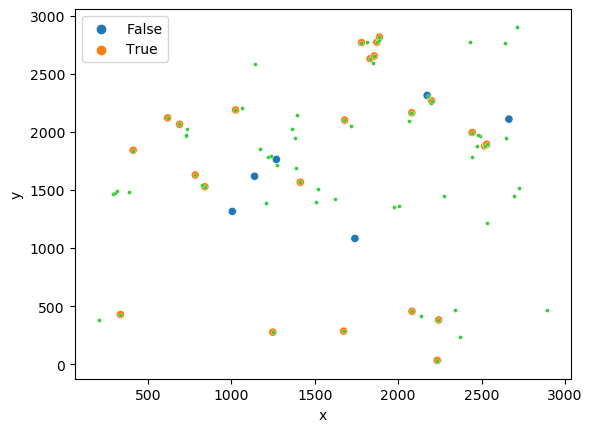

20X_c0-DAPI_A1_Tile-110


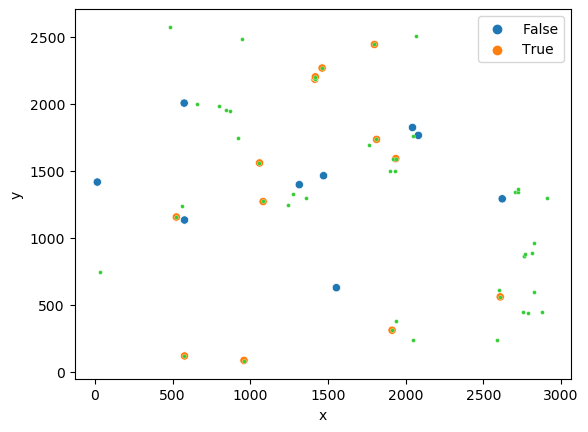

20X_c0-DAPI_A1_Tile-130


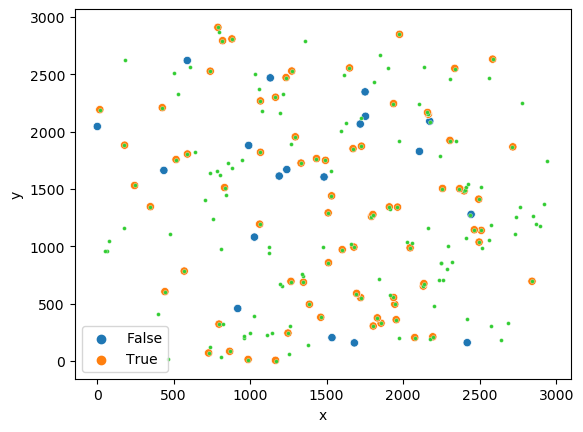

20X_c0-DAPI_A1_Tile-90


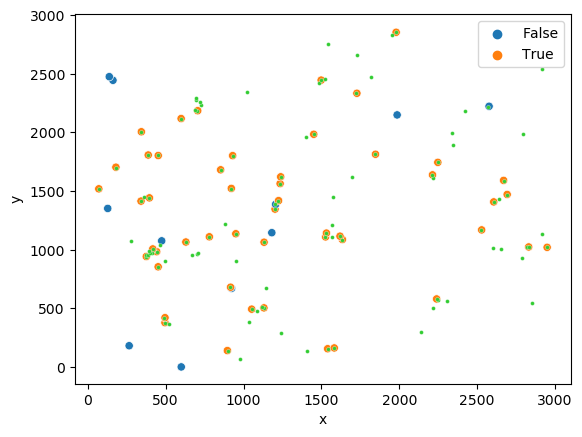

20X_c0-DAPI_A1_Tile-150


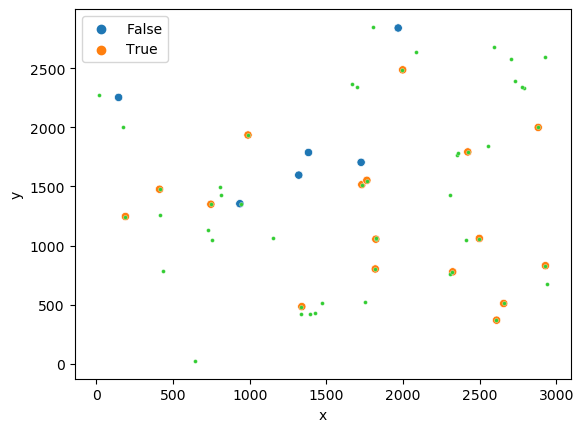

20X_c0-DAPI_A1_Tile-70


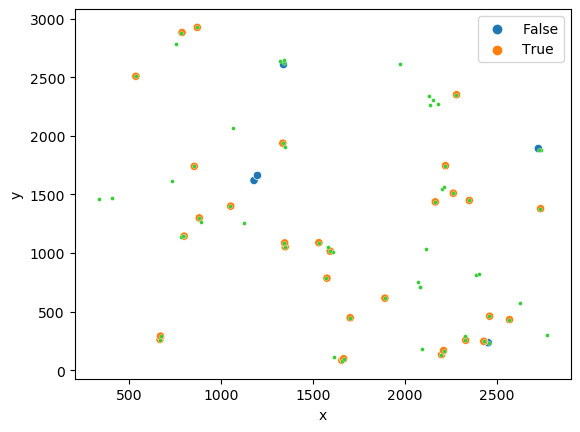

20X_c0-DAPI_A1_Tile-10


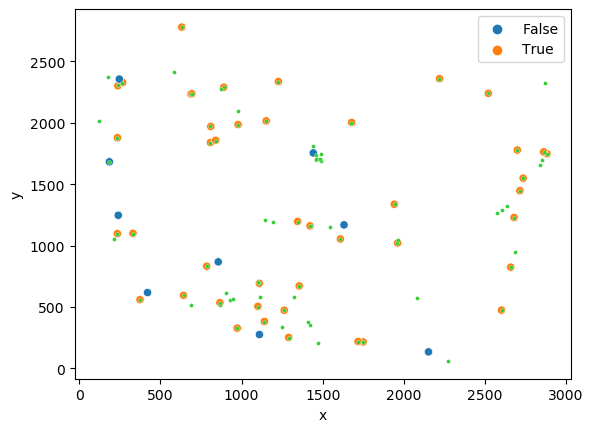

20X_c0-DAPI_A1_Tile-50


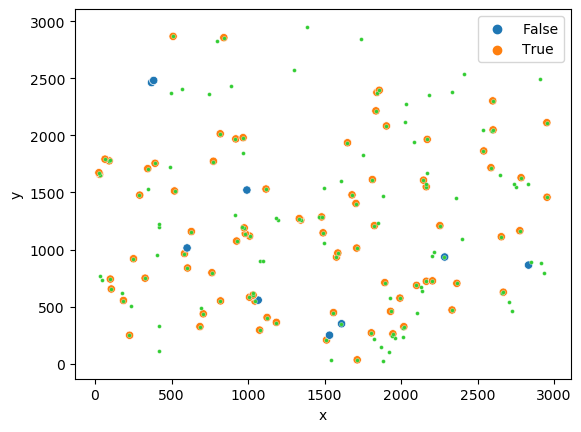

20X_c0-DAPI_A1_Tile-170


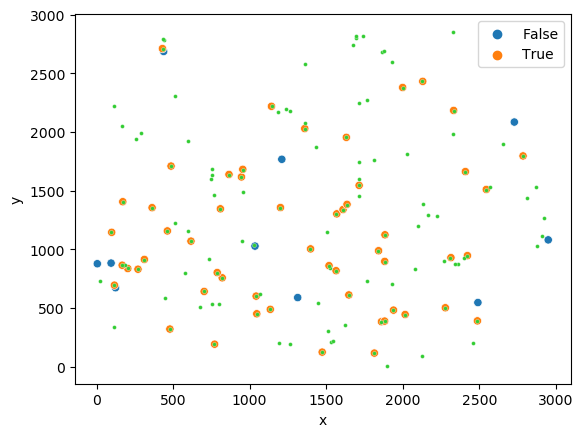

20X_c0-DAPI_A1_Tile-30


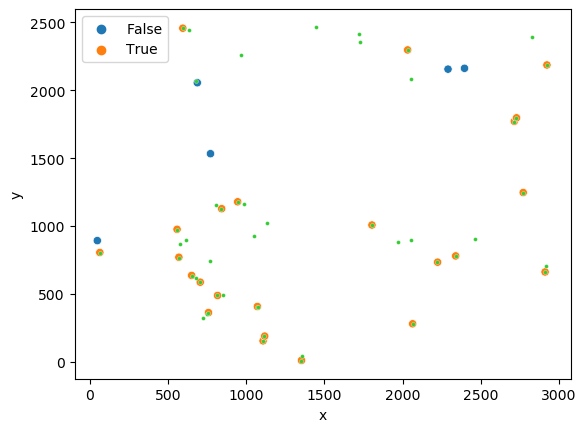

In [6]:
performance = []
for i in range(len(annot_files)):
    # Select image for analysis
    validation_file = annot_files[i]
    imid = validation_file.split('.')[0]
    print(imid)
    
    # Load image and annotations
    im = mnds.read_image(DIRECTORY, imid, 'phenotype.tif', scale=SCALE_FACTOR)
    gt = mnds.read_micronuclei_annotations(DIRECTORY, imid)
    fim = mnds.read_image(mnfinder_dir, imid, 'micronuclei.tif', scale=SCALE_FACTOR)
    
    # Parse detections
    detections = []
    for k in np.unique(fim)[1:]:
        y,x = np.where(fim == k)
        detections.append({"x":np.mean(x), "y":np.mean(y), "area":len(fim[x,y])})
    detections = pd.DataFrame(detections)
    
    # Find matches
    A = np.asarray(gt[["x","y"]])
    B = np.asarray(detections[["x","y"]])  
    D = scipy.spatial.distance_matrix(A,B)
    matches = np.argmin(D, axis=0)
    dist = np.min(D, axis=0)
    detections["match"] = dist < 5
        
    # Compute performance
    tp = detections.match.sum()
    fp = len(detections) - tp
    fn = len(gt) - tp
    prec = tp / len(detections)
    recall = tp / len(gt)
    performance.append({"imid":imid, "true_positives": tp, "false_positives": fp, "false_negatives": fn,
                        "precision": prec, "recall": recall, "f1-score": 2*(prec*recall)/(prec+recall)})
    
    # Show matches
    plt.figure()
    sb.scatterplot(data=detections, x="x", y="y", hue="match")
    sb.scatterplot(data=gt, x="x", y="y",s=8, color="limegreen")
    plt.show()
    

In [7]:
p = pd.DataFrame(performance)

In [8]:
p

,imid,true_positives,false_positives,false_negatives,precision,recall,f1-score
0,20X_c0-DAPI_A1_Tile-190,24,6,49,0.800000,0.328767,0.466019
1,20X_c0-DAPI_A1_Tile-110,13,9,35,0.590909,0.270833,0.371429
2,20X_c0-DAPI_A1_Tile-130,75,19,104,0.797872,0.418994,0.549451
3,20X_c0-DAPI_A1_Tile-90,50,11,58,0.819672,0.462963,0.591716
4,20X_c0-DAPI_A1_Tile-150,17,6,34,0.739130,0.333333,0.459459
5,20X_c0-DAPI_A1_Tile-70,31,5,36,0.861111,0.462687,0.601942
6,20X_c0-DAPI_A1_Tile-10,44,9,41,0.830189,0.517647,0.637681
7,20X_c0-DAPI_A1_Tile-50,82,9,76,0.901099,0.518987,0.658635
8,20X_c0-DAPI_A1_Tile-170,55,10,79,0.846154,0.410448,0.552764
9,20X_c0-DAPI_A1_Tile-30,24,5,25,0.827586,0.489796,0.615385


In [9]:
p.mean()

/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


true_positives     41.500000
false_positives     8.900000
false_negatives    53.700000
precision           0.801372
recall              0.421446
f1-score            0.550448
dtype: float64